In [3]:
# Install required libraries
!pip install kagglehub tensorflow opencv-python scikit-learn matplotlib

In [4]:
import kagglehub
import os
import cv2
import numpy as np
import collections
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint

In [5]:
# Download dataset and set correct path
path = kagglehub.dataset_download("gti-upm/leapgestrecog")
data_dir = os.path.join(path, "leapGestRecog", "00")  # use single subject folder like "00" for better balance
print("Using data directory:", data_dir)

def load_data(image_size=(64, 64)):
    X, y = [], []
    gestures = sorted([d for d in os.listdir(data_dir) if not d.startswith('.') and os.path.isdir(os.path.join(data_dir, d))])

    for label, gesture in enumerate(gestures):
        gesture_path = os.path.join(data_dir, gesture)
        for file in os.listdir(gesture_path):
            if not file.endswith(".png"):
                continue
            img_path = os.path.join(gesture_path, file)
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            if img is not None:
                img = cv2.resize(img, image_size)
                X.append(img)
                y.append(label)

    if len(X) == 0:
        raise ValueError("No images loaded. Check if dataset path is correct and contains PNG images.")

    X = np.array(X).reshape(-1, image_size[0], image_size[1], 1) / 255.0
    y = np.array(y)
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y), gestures


Using data directory: C:\Users\Mamba\.cache\kagglehub\datasets\gti-upm\leapgestrecog\versions\1\leapGestRecog\00


In [6]:
# Load data
(X_train, X_test, y_train, y_test), gesture_labels = load_data()
print("Data loaded successfully. Shapes:")
print(X_train.shape, y_train.shape)


Data loaded successfully. Shapes:
(1600, 64, 64, 1) (1600,)


In [10]:
# Check class distribution in test set
print("Class distribution in y_test:", collections.Counter(y_test))

# Convert labels to categorical format
num_classes = len(gesture_labels)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
print(f"y_train shape: {y_train_cat.shape}")
print(f"y_test shape: {y_test_cat.shape}")


Class distribution in y_test: Counter({7: 40, 6: 40, 1: 40, 2: 40, 5: 40, 4: 40, 8: 40, 9: 40, 3: 40, 0: 40})
y_train shape: (1600, 10)
y_test shape: (400, 10)


Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 177ms/step - accuracy: 0.3509 - loss: 1.8819 - val_accuracy: 0.9950 - val_loss: 0.1445
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 153ms/step - accuracy: 0.9426 - loss: 0.2361 - val_accuracy: 0.9975 - val_loss: 0.0105
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.9831 - loss: 0.0572 - val_accuracy: 1.0000 - val_loss: 0.0025
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - accuracy: 0.9866 - loss: 0.0447 - val_accuracy: 1.0000 - val_loss: 0.0016
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9961 - loss: 0.0246 - val_accuracy: 1.0000 - val_loss: 7.1293e-04
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.9962 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 0.0017
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.9965 - loss: 0.0233 - val_accuracy: 1.0000 - val_loss: 4.4781e-04
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.9973 - loss: 0.0123 - val_accu

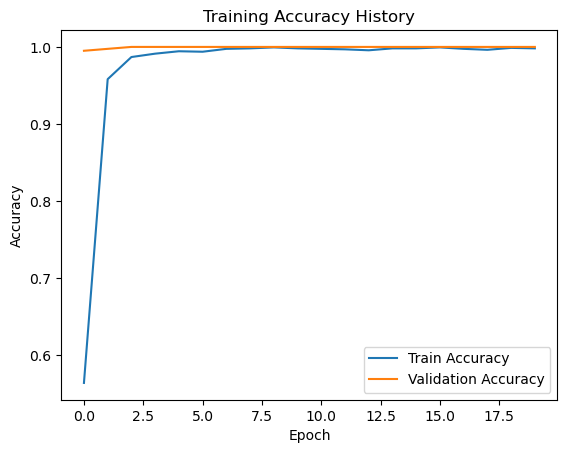

In [9]:
# Define CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
checkpoint = ModelCheckpoint('gesture_model.keras', save_best_only=True)

# Train model and track history
history = model.fit(X_train, y_train_cat, validation_data=(X_test, y_test_cat), epochs=20, batch_size=64, callbacks=[checkpoint])

# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Training Accuracy History')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()


In [12]:
# Evaluate model
model.load_weights('gesture_model.keras')
predictions = model.predict(X_test)
pred_labels = np.argmax(predictions, axis=1)

print("Classification Report:")
print(classification_report(y_test, pred_labels, target_names=gesture_labels, zero_division=0))

print("Confusion Matrix:")
print(confusion_matrix(y_test, pred_labels))

# Print some actual vs predicted gesture labels
for i in range(5):
    print(f"Actual: {gesture_labels[y_test[i]]}, Predicted: {gesture_labels[pred_labels[i]]}")


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Classification Report:
               precision    recall  f1-score   support

      01_palm       1.00      1.00      1.00        40
         02_l       1.00      1.00      1.00        40
      03_fist       1.00      1.00      1.00        40
04_fist_moved       1.00      1.00      1.00        40
     05_thumb       1.00      1.00      1.00        40
     06_index       1.00      1.00      1.00        40
        07_ok       1.00      1.00      1.00        40
08_palm_moved       1.00      1.00      1.00        40
         09_c       1.00      1.00      1.00        40
      10_down       1.00      1.00      1.00        40

     accuracy                           1.00       400
    macro avg       1.00      1.00      1.00       400
 weighted avg       1.00      1.00      1.00       400

Confusion Matrix:
[[40  0  0  0  0  0  0  0  0  0]
 [ 0 40  0  0  0  0  0  0  0  0]
 [ 0  0 40  0  0  0  0  0  0  0]
 [ 0  0  0 40  0  0  0  0  0  0]
 [ 0  0  0  0 